<a href="https://colab.research.google.com/github/Jana-Alothman/GP1/blob/main/Arabic_Readability_Classification_On_BAREC_Corpus_Using_Temp_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Arabic Readability Classification On BAREC Corpus Using Temp Model**


This notebook presents the implementation of Temp for Arabic readability classification using the BAREC Corpus.

The experiments use TF-IDF features extracted from Arabic text and evaluate the model under two readability classification schemes: 19-level and 5-level.

A baseline model is first established using the default hyperparameters, followed by hyperparameter tuning using GridSearchCV to identify the optimal regularization parameter.

Finally, the tuned model is evaluated with and without class balancing, and the performance of all models is compared using multiple evaluation metrics.

# **Data Collection**

**Dataset Source:**

In this project, the dataset used for Arabic readability assessment was obtained from BAREC Corpus v1.0 on Hugging Face.

---
**Research paper:**

A Large and Balanced Corpus for Fine-grained Arabic Readability Assessment.

---

**Data Fields:**
- ID: Unique sentence identifier.
- Sentence: The sentence text.
- Word_Count: Number of words in the sentence.
- Word: Simply tokenized and dediacritized sentences.
- Lex: Each word is replaced by its predicited lemma (dediacritized).
- D3Tok: We tokenize words into their base and clitics forms.
- D3Lex: We replace the base forms in D3Tok with the predicited lemmas.
- Readability_Level: The readability level in 19-levels scheme, ranging from 1-alif to 19-qaf.
- Readability_Level_19: The readability level in 19-levels scheme, ranging from 1 to 19.
- Readability_Level_7: The readability level in 7-levels scheme, ranging from 1 to 7.
- Readability_Level_5: The readability level in 5-levels scheme, ranging from 1 to 5.
- Readability_Level_3: The readability level in 3-levels scheme, ranging from 1 to 3.
- Annotator: The annotator ID (A1-A5 or IAA).
- Document: Source document file name.
- Source: Document source.
- Book: Book name.
- Author: Author name.
- Domain: Domain (Arts & Humanities, STEM or Social Sciences).
- Text_Class: Readership group (Foundational, Advanced or Specialized).

---
**Supported Tasks:**

The dataset supports multi-class readability classification in the following formats:

- 19 levels (default)
- 7 levels
- 5 levels
- 3 levels

---
**Data Splits:**
- The BAREC dataset has three splits: Train (80%), Dev (10%), and Test (10%).
- The splits are in the document level.
- The splits are balanced accross Readability Levels, Domains, and Text Classes.



In [2]:
# Install required libraries for dataset loading and processing.

!pip install datasets pandas

In [3]:
# Load the BAREC dataset and display dataset splits and columns.

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("CAMeL-Lab/BAREC-Corpus-v1.0")

# Load each split separately
train_df = dataset["train"].to_pandas()
dev_df = dataset["dev"].to_pandas()
test_df = dataset["test"].to_pandas()
full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

# Display split sizes
print("Train Shape:", train_df.shape)
print("Validation Shape:", dev_df.shape)
print("Test Shape:", test_df.shape)
print("Full Dataset Shape:", full_df.shape)

print("\nDataset Columns:\n")
print(full_df.columns)

print("\nSample Data:\n")
full_df.head()

README.md:   0%|          | 0.00/6.19k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.9MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/dev-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.37MB            

data/dev-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/54845 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/7310 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7286 [00:00<?, ? examples/s]

Train Shape: (54845, 19)
Validation Shape: (7310, 19)
Test Shape: (7286, 19)
Full Dataset Shape: (69441, 19)

Dataset Columns:

Index(['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex',
       'Readability_Level', 'Readability_Level_19', 'Readability_Level_7',
       'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Document',
       'Source', 'Book', 'Author', 'Domain', 'Text_Class'],
      dtype='object')

Sample Data:



,ID,Sentence,Word_Count,Word,Lex,D3Tok,D3Lex,Readability_Level,Readability_Level_19,Readability_Level_7,Readability_Level_5,Readability_Level_3,Annotator,Document,Source,Book,Author,Domain,Text_Class
0,10100290001,مجلة كل الأولاد وكل البنات,5,مجلة كل الأولاد وكل البنات,مجلة كل ولد كل بنت,مجلة كل ال+ أولاد و+ كل ال+ بنات,مجلة كل ال+ ولد و+ كل ال+ بنت,7-zay,7,2,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
1,10100290002,ماجد,1,ماجد,ماجد,ماجد,ماجد,1-alif,1,1,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
2,10100290003,الأربعاء 21 يناير 1987,4,الأربعاء 21 يناير 1987,أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,8-Ha,8,3,2,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
3,10100290004,الموافق 21 جمادى الأول 1407هــ,6,الموافق 21 جمادى الأول 1407ه,موافق 21 جمادى أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,7-zay,7,2,1,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
4,10100290005,السنة الثامنة,2,السنة الثامنة,سنة ثامن,ال+ سنة ال+ ثامنة,ال+ سنة ال+ ثامن,5-ha,5,2,1,1,A4,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational


In [4]:
# Save the complete dataset as a CSV file.

full_df.to_csv("BAREC_full.csv", index=False)

In [5]:
# Create a filtered version containing selected columns only.

filtered_full_df = full_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_train_df = train_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_dev_df = dev_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_test_df = test_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_full_df.to_csv("BAREC_full_filtered.csv", index=False)
filtered_full_df.head()

,Word,Word_Count,Domain,Text_Class,Readability_Level_19,Readability_Level_5
0,مجلة كل الأولاد وكل البنات,5,Arts & Humanities,Foundational,7,1
1,ماجد,1,Arts & Humanities,Foundational,1,1
2,الأربعاء 21 يناير 1987,4,Arts & Humanities,Foundational,8,2
3,الموافق 21 جمادى الأول 1407ه,6,Arts & Humanities,Foundational,7,1
4,السنة الثامنة,2,Arts & Humanities,Foundational,5,1


**Feature Selection Justification**

Only the **Word** column was used as the input feature because this study aims to classify readability using textual information represented by TF-IDF features.

The remaining columns were excluded for the following reasons:

---

**Text Variations (Sentence, Lex, D3Tok, D3Lex)**

These columns are different linguistic transformations of the same sentence.

- They represent the same original text in different formats  

---

**Alternative Readability Levels (3, 7-level schemes)**

These columns represent the same target variable (readability) but on different scales.

- They contain overlapping information with the main target (19 & 5 -level scales)


---

**Metadata Columns (ID, Annotator, Document, Source, Book, Author)**

These columns are not useful for prediction.

- They are administrative or contextual only
- They do not contribute to readability prediction

---

**Final Selected Features**

The final dataset used for modeling includes:

- **Word** → main input text
- **Word_Count** → length-based feature
- **Domain** → topic/category information
- **Text_Class** → readership group
- **Readability_Level_19** → target label
- **Readability_Level_5** → target label

In [6]:
# Download both the full and filtered datasets.

from google.colab import files

#files.download("BAREC_full.csv")
#files.download("BAREC_full_filtered.csv")

# **Data Preprocessing**

In this stage, we perform preprocessing on the **filtered dataset** to ensure it is clean, consistent, and ready for machine learning.

## 1. Checking Missing Values

We first check whether the dataset contains any missing values.

Even if the dataset is clean, this step ensures there are no hidden nulls that could affect model training.

In [7]:
filtered_full_df.isnull().sum()

,0
Word,0
Word_Count,0
Domain,0
Text_Class,0
Readability_Level_19,0
Readability_Level_5,0


**Interpretation:** The dataset shows no missing values across all selected features, indicating that the data is complete and well-structured.

## 2. Checking Duplicate Rows

We check for duplicate rows to make sure the model does not learn repeated examples that could bias training.

In [8]:
beforeFull = filtered_full_df.duplicated().sum()
beforeTrain = filtered_train_df.duplicated().sum()
beforeDev = filtered_dev_df.duplicated().sum()
beforeTest = filtered_test_df.duplicated().sum()

print("Before dropping duplicates (Full) = " , beforeFull)
print("Before dropping duplicates (Train) = " , beforeTrain)
print("Before dropping duplicates (Dev) = " , beforeDev)
print("Before dropping duplicates (Test) = " , beforeTest)

Before dropping duplicates (Full) =  3542
Before dropping duplicates (Train) =  2670
Before dropping duplicates (Dev) =  195
Before dropping duplicates (Test) =  213


In [9]:
afterFull = filtered_full_df.drop_duplicates().duplicated().sum()
afterTrain = filtered_train_df.drop_duplicates().duplicated().sum()
afterDev = filtered_dev_df.drop_duplicates().duplicated().sum()
afterTest = filtered_test_df.drop_duplicates().duplicated().sum()

print("After dropping duplicates (Full) = " , afterFull)
print("After dropping duplicates (Train) = " , afterTrain)
print("After dropping duplicates (Dev) = " , afterDev)
print("After dropping duplicates (Test) = " , afterTest)

After dropping duplicates (Full) =  0
After dropping duplicates (Train) =  0
After dropping duplicates (Dev) =  0
After dropping duplicates (Test) =  0


**Interpretation:** 3,542 duplicate rows were found in the dataset, indicating repeated samples. These duplicates were removed to prevent bias and ensure the model does not learn from repeated instances of the same data.

## 3. Checking Label Distribution

We analyze the distribution of the 19-level and 5-level readability classes to understand whether the dataset is balanced or imbalanced.

In [10]:
filtered_full_df["Readability_Level_19"].value_counts().sort_index()

,count
Readability_Level_19,
1,409
2,437
3,1462
4,751
5,3443
6,1534
7,5438
8,5683
9,2023


In [11]:
filtered_full_df["Readability_Level_5"].value_counts().sort_index()

,count
Readability_Level_5,
1,13474
2,22383
3,18510
4,13234
5,1840


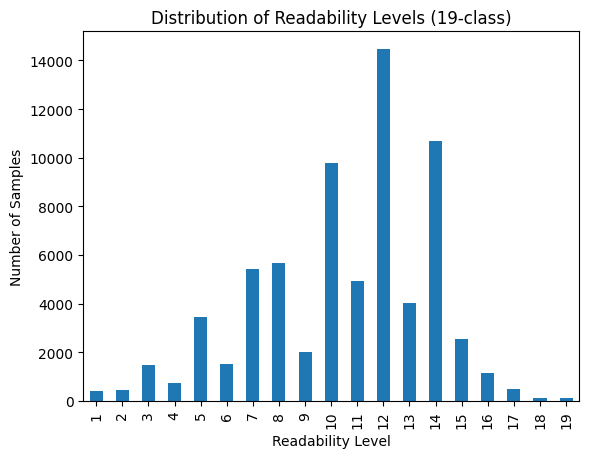

In [12]:
import matplotlib.pyplot as plt

full_df["Readability_Level_19"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (19-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

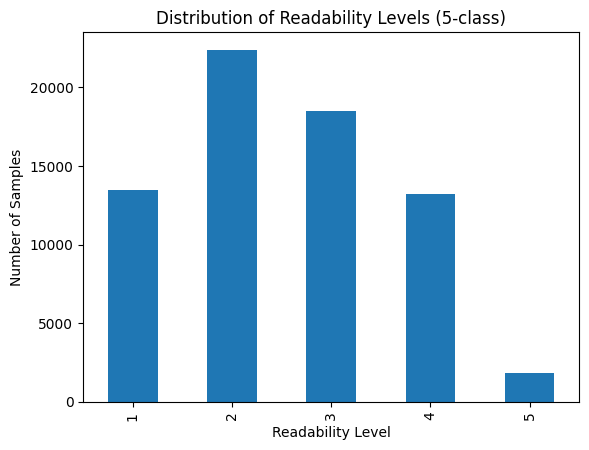

In [13]:
import matplotlib.pyplot as plt

full_df["Readability_Level_5"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (5-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

**Interpretation:** The dataset shows a clear class imbalance across the 19 and 5 readability levels. Some classes contain a significantly higher number of samples, while higher levels have very few instances. This imbalance may affect model performance and bias predictions toward majority classes.

#**Model Training**

##**Temp Model**

**Why Temp?**

...

##**Temp Feature Extraction using TF-IDF**

The input text was converted into numerical feature vectors using the TF-IDF (Term Frequency–Inverse Document Frequency) representation.

In [ ]:
# Import TF-IDF vectorizer for converting text into numerical feature vectors
from sklearn.feature_extraction.text import TfidfVectorizer

# Define input text and target labels
temp_X_train = filtered_train_df["Word"]
temp_X_dev = filtered_dev_df["Word"]
temp_X_test = filtered_test_df["Word"]

# Create TF-IDF features using unigrams and bigrams
temp_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2)
)

# Fit TF-IDF on the training set and transform all data splits
temp_X_train_tfidf = svm_vectorizer.fit_transform(temp_X_train)
temp_X_dev_tfidf = svm_vectorizer.transform(temp_X_dev)
temp_X_test_tfidf = svm_vectorizer.transform(temp_X_test)

**ngram_range Justification**


The parameter `ngram_range=(1,2)` was selected to include both **unigrams** (single words) and **bigrams** (pairs of consecutive words). While unigrams capture the importance of individual words, bigrams preserve short contextual information that may improve the model's ability to distinguish different readability levels.

This configuration is widely adopted in text classification tasks because it provides a good balance between capturing contextual information and maintaining computational efficiency.

---

##**Model Evaluation Function**

**Evaluation Metrics Overview:**

The model is evaluated using multiple metrics to properly reflect its performance on an ordinal readability classification task.

- **Quadratic Weighted Kappa (QWK):** Primary metric that measures agreement between predicted and actual labels while penalizing larger errors more heavily.
- **Accuracy:** Measures exact match between predicted and true labels.
- **Acc ±1:** Considers predictions correct if they are within one level of the true label.
- **Macro F1-score:** Evaluates performance equally across all classes, making it suitable for imbalanced datasets.
- **Precision & Recall:** Measure class-level prediction quality and coverage.
- **Confusion Matrix:** Provides detailed insight into misclassification patterns.
- **MAE/Distance (Mean Absolute Error)**: The average absolute difference between predicted and true values. Treats all errors equally. Lower is better.
- **RMSE (Root Mean Square Error):** The square root of the average squared difference between predicted and true values. Penalizes large errors more heavily than MAE. Lower is better.
- **R² Score:** Indicates how well predictions explain variance in readability levels, though less common for classification tasks.

In [ ]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    cohen_kappa_score,
    r2_score
)

import numpy as np


def evaluate_svm_model(y_true, y_pred, dataset_name):
    """
    Evaluate a Linear SVM model using multiple classification metrics.
    """

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_true, y_pred)
    adj_accuracy = np.mean(np.abs(y_true - y_pred) <= 1)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Print results
    print("=" * 60)
    print(dataset_name)
    print("=" * 60)

    print(f"Accuracy:                      {accuracy:.4f}")
    print(f"Adjacent Accuracy (±1):        {adj_accuracy:.4f}")
    print(f"Quadratic Weighted Kappa:      {qwk:.4f}")
    print(f"Macro F1-score:                {macro_f1:.4f}")
    print(f"Weighted Precision:            {precision:.4f}")
    print(f"Weighted Recall:               {recall:.4f}")
    print(f"Mean Absolute Error (MAE):     {mae:.4f}")
    print(f"Root Mean Squared Error:       {rmse:.4f}")
    print(f"R² Score:                      {r2:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

**How to call the function?**

evaluate_temp_model(
    temp_y_test,
    temp_baseline_19_test_pred,
    "Baseline Temp (19-Level) - Test Set"
)

##**Confusion Matrix Function**

In [ ]:
# Import libraries for confusion matrix visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels, title):
    """
    Plot a confusion matrix for a classification model.
    """

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()

**How to call the function?**

plot_confusion_matrix(
    temp_y_test,
    temp_baseline_19_test_pred,
    labels=list(range(1,20)),
    title="Confusion Matrix - Baseline Temp(19-Level)"
)

---

##**Temp Baseline Model (19-Level)**

In [ ]:
# Define target labels for the 19-level classification task

temp_y_train_19 = filtered_train_df["Readability_Level_19"]
temp_y_dev_19 = filtered_dev_df["Readability_Level_19"]
temp_y_test_19 = filtered_test_df["Readability_Level_19"]

In [ ]:
# Import Temp Classifier
from sklearn.svm import LinearSVC

# Create the Temp model using default hyperparameters
temp_baseline_19 = LinearSVC(
    random_state=42
)

print(temp_baseline_19.get_params())

{'C': 1.0, 'class_weight': None, 'dual': 'auto', 'fit_intercept': True, 'intercept_scaling': 1, 'loss': 'squared_hinge', 'max_iter': 1000, 'multi_class': 'ovr', 'penalty': 'l2', 'random_state': 42, 'tol': 0.0001, 'verbose': 0}


In [ ]:
# Train the baseline model
temp_baseline_19.fit(
    temp_X_train_tfidf,
    temp_y_train
)

LinearSVC(random_state=42)

In [ ]:
# Generate predictions using the baseline SVM model
temp_baseline_19_test_pred = temp_baseline_19.predict(temp_X_test_tfidf)

In [ ]:
evaluate_temp_model(
    temp_y_test,
    temp_baseline_19_test_pred,
    "Baseline Temp (19-Level) - Test Set"
)

Baseline SVM (19-Level) - Test Set
Accuracy:                      0.3833
Adjacent Accuracy (±1):        0.5102
Quadratic Weighted Kappa:      0.5492
Macro F1-score:                0.2769
Weighted Precision:            0.3704
Weighted Recall:               0.3833
Mean Absolute Error (MAE):     1.9484
Root Mean Squared Error:       2.9909
R² Score:                      0.1583

Classification Report:

              precision    recall  f1-score   support

           1       0.40      0.53      0.45        32
           2       0.35      0.19      0.25        36
           3       0.42      0.40      0.41       141
           4       0.34      0.26      0.29        86
           5       0.51      0.45      0.48       380
           6       0.42      0.23      0.30       139
           7       0.47      0.44      0.45       585
           8       0.33      0.38      0.35       541
           9       0.45      0.39      0.42       190
          10       0.43      0.49      0.46      1010
   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

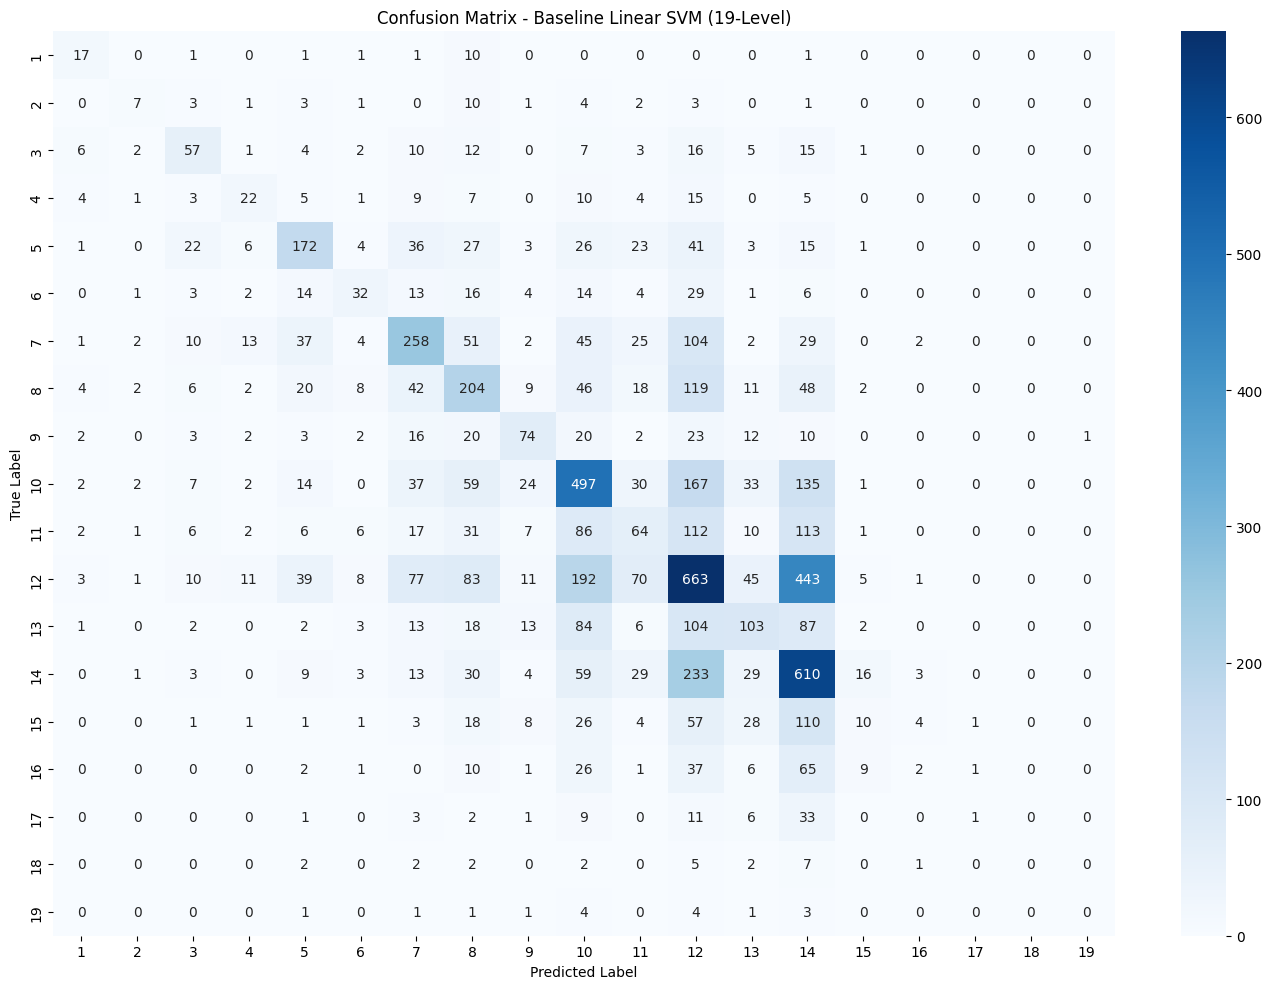

In [ ]:
plot_confusion_matrix(
    temp_y_test,
    temp_baseline_19_test_pred,
    labels=list(range(1,20)),
    title="Confusion Matrix - Baseline Temp (19-Level)"
)

###**Temp Baseline Findings (19-Level)**
..

##**Temp Hyperparameter Tunning Using GridSearchCV (19-Level)**


**Hyperparameter Search Space Justification**

...


**References**

...


In [ ]:
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Define the search space for the ...
param_grid = {

}

# Create GridSearchCV object
temp_grid_19 = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Perform hyperparameter tuning on the training set
temp_grid_19.fit(
    temp_X_train_tfidf,
    temp_y_train_19
)

# Print the best hyperparameter and cross-validation accuracy
print("Best Parameters:", temp_grid_19.best_params_)
print(f"Best 5-Fold Cross-Validation Accuracy: {temp_grid_19.best_score_:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Parameters: {'C': 1}
Best 5-Fold Cross-Validation Accuracy: 0.3277


##**Temp Tuned Model (19-Level)**
* **class_weight: Balanced**

In [ ]:
#Your Code

###**Temp Tunned Findings (19-Level)**
* **class_weight: Balanced**

..

##**Temp Tuned Model (19-Level)**
* **class_weight: None**

In [ ]:
#Your Code

###**Temp Tunned Findings (19-Level)**
* **class_weight: None**

..

---

##**Temp Baseline Model (5-Level)**

In [ ]:
# Define target labels for the 5-level classification task

temp_y_train_5 = filtered_train_df["Readability_Level_5"]
temp_y_dev_5 = filtered_dev_df["Readability_Level_5"]
temp_y_test_5 = filtered_test_df["Readability_Level_5"]

###**Temp Baseline Findings (5-Level)**
..

##**Temp Hyperparameter Tunning Using GridSearchCV (5-Level)**

##**Temp Tuned Model (5-Level)**
* **class_weight: Balanced**

In [ ]:
#Your Code

###**Temp Tunned Findings (5-Level)**
* **class_weight: Balanced**

..

##**Temp Tuned Model (5-Level)**
* **class_weight: None**

In [ ]:
#Your Code

###**Temp Tunned Findings (5-Level)**
* **class_weight: None**

..

#**Comparison between 19 & 5 Level Results**

Tabel goes here ...
